# Benna & Fusi (2021) — Step 2: Sparse Autoencoder on Ultrametric Patterns

Replicates **Figures 2B and 2C** from the paper.

**Setup:** A sparse autoencoder is trained to compress ultrametric binary patterns.  
- Input (EC): N=300 neurons, binary patterns with coding level ≈ 0.5  
- Hidden (DG): N=600 neurons, sigmoid activations, KL sparsity penalty → coding level ≈ 0.1  

**Fig 2B** — geometry: intra-class Pearson correlations (same ancestor) vs branching ratio k.  
- Autoencoder decorrelates more aggressively as k increases (more compressible environment).  
- Random encoder shows no dependence on k.

**Fig 2C** — memory capacity: how many patterns can be correctly reconstructed  
from noisy cues (overlap 0.8 with original), as a function of total stored memories.

> **Runtime:** Fig 2B trains 8 autoencoders (~4 min CPU), Fig 2C trains ~20 more (~10 min CPU).

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import os, warnings

warnings.filterwarnings('ignore')
os.makedirs('../results/figs/fig2', exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('PyTorch:', torch.__version__)

PyTorch: 2.11.0+cpu


In [2]:
# ── Paper hyperparameters ──────────────────────────────────────────────────
N_INPUT   = 300      # EC / input layer size
N_HIDDEN  = 600      # DG / compressed layer size
GAMMA     = 0.6      # similarity of descendants to their ancestor
P_TOTAL   = 300      # total patterns (fixed for Fig 2B)
FSPARSE   = 0.1      # target hidden coding level (sparsity)
BETA_KL   = 5.0      # sparsity regularisation coefficient
LAMBDA_L2 = 1e-5     # L2 weight regularisation
N_EPOCHS  = 600      # training epochs (paper: 600)
LR        = 0.01     # Adam learning rate
BIN_THR   = 0.5      # threshold for binarising hidden representations

# Branching ratios for Fig 2B (same values as paper)
K_VALS_2B = [10, 20, 30, 60, 75, 100, 150, 300]

## 1. Pattern generation

Ancestors: binary (0/1), each neuron active with probability 0.5 → coding level ≈ 0.5.  
Descendants: each neuron is resampled with probability (1 − γ), kept otherwise.  

Expected intra-class Pearson correlation between two descendants of the same ancestor = γ².

In [3]:
def generate_ultrametric(N, p, k, gamma, seed=SEED):
    """
    Generate binary ultrametric patterns.
    Returns ancestors (p, N), descendants (p*k, N), labels (p*k,).
    """
    rng = np.random.default_rng(seed)
    ancestors = rng.integers(0, 2, size=(p, N)).astype(np.float32)
    descendants, labels = [], []
    for i, anc in enumerate(ancestors):
        for _ in range(k):
            mask = rng.random(N) < (1 - gamma)   # positions to resample
            desc = anc.copy()
            desc[mask] = rng.integers(0, 2, size=mask.sum()).astype(np.float32)
            descendants.append(desc)
            labels.append(i)
    return ancestors, np.array(descendants, dtype=np.float32), np.array(labels)


def pearson(a, b):
    """Pearson correlation between two 1-D arrays."""
    a, b = a - a.mean(), b - b.mean()
    denom = np.sqrt((a**2).sum() * (b**2).sum())
    return float((a * b).sum() / denom) if denom > 1e-10 else 0.0


def intra_class_corr(X, labels, max_pairs_per_class=10):
    """Average Pearson correlation between same-class pairs."""
    corrs = []
    for lbl in np.unique(labels):
        idx = np.where(labels == lbl)[0]
        for i in range(len(idx)):
            for j in range(i + 1, min(i + 1 + max_pairs_per_class, len(idx))):
                corrs.append(pearson(X[idx[i]], X[idx[j]]))
    return float(np.mean(corrs)) if corrs else 0.0


# Quick sanity check
_, desc_test, lbl_test = generate_ultrametric(N_INPUT, p=10, k=20, gamma=GAMMA)
c = intra_class_corr(desc_test, lbl_test)
print(f'Intra-class correlation: {c:.3f}  (expected γ² = {GAMMA**2:.3f})')

Intra-class correlation: 0.363  (expected γ² = 0.360)


## 2. Sparse autoencoder

Architecture: `sigmoid(W_enc x + b_enc)` → hidden h → `sigmoid(W_dec h + b_dec)` → reconstruction.

Loss = MSE reconstruction + β · Σⱼ KL(ρ ‖ ρ̂ⱼ) + λ · ‖W‖²

where ρ = FSPARSE (target), ρ̂ⱼ = mean activation of hidden unit j across all patterns.

In [4]:
class SparseAE(nn.Module):
    def __init__(self, n_in, n_hid):
        super().__init__()
        self.enc = nn.Linear(n_in, n_hid)
        self.dec = nn.Linear(n_hid, n_in)
        nn.init.normal_(self.enc.weight, 0, 0.1)
        nn.init.zeros_(self.enc.bias)
        nn.init.normal_(self.dec.weight, 0, 0.1)
        nn.init.zeros_(self.dec.bias)

    def forward(self, x):
        h = torch.sigmoid(self.enc(x))
        return torch.sigmoid(self.dec(h)), h

    def encode(self, x):
        return torch.sigmoid(self.enc(x))


def kl_penalty(rho, rho_hat):
    """KL divergence between Bernoulli(rho) and Bernoulli(rho_hat)."""
    eps = 1e-8
    rho_hat = rho_hat.clamp(eps, 1 - eps)
    return (rho * torch.log(torch.tensor(rho + eps) / rho_hat)
            + (1 - rho) * torch.log(torch.tensor(1 - rho + eps) / (1 - rho_hat)))


def train_ae(X, n_hid=N_HIDDEN, rho=FSPARSE, beta=BETA_KL,
             lam=LAMBDA_L2, n_epochs=N_EPOCHS, lr=LR, seed=SEED):
    """Train sparse autoencoder. Returns trained model."""
    torch.manual_seed(seed)
    model = SparseAE(X.shape[1], n_hid)
    opt = Adam(model.parameters(), lr=lr)
    Xt = torch.FloatTensor(X)

    for _ in range(n_epochs):
        model.train()
        opt.zero_grad()
        x_hat, h = model(Xt)
        recon = F.mse_loss(x_hat, Xt)
        rho_hat = h.mean(dim=0)                        # mean activation per unit
        kl = kl_penalty(rho, rho_hat).sum()
        l2 = sum(p.pow(2).sum() for p in model.parameters())
        (recon + beta * kl + lam * l2).backward()
        opt.step()

    return model


@torch.no_grad()
def get_hidden(model, X, thr=BIN_THR):
    """Return (continuous, binarised) hidden representations."""
    model.eval()
    h = model.encode(torch.FloatTensor(X)).numpy()
    return h, (h > thr).astype(np.float32)


def rand_encoder(X, n_hid, f_target, seed=SEED):
    """Random Gaussian projection + threshold to match target coding level."""
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((n_hid, X.shape[1])).astype(np.float32)
    h = 1 / (1 + np.exp(-(X @ W.T)))                  # sigmoid
    thr = np.percentile(h, (1 - f_target) * 100)
    return (h > thr).astype(np.float32)

## 3. Figure 2B — geometry of compressed representations

For each branching ratio k (P=300 total patterns, p=P//k ancestors):  
- Train sparse autoencoder  
- Compute intra-class Pearson correlation for: inputs, AE hidden, random encoder (f=0.1 and f=0.5)

**Expected:** AE correlations drop as k increases (more compressible → more decorrelated).  
Input stays at γ² ≈ 0.36 regardless of k.

In [5]:
res2b = {key: [] for key in ['k', 'inp', 'ae', 'rand01', 'rand05']}

for ki, k in enumerate(K_VALS_2B):
    p = max(1, P_TOTAL // k)
    # regenerate patterns fresh per k so p*k ≈ P_TOTAL
    _, desc, lbl = generate_ultrametric(N_INPUT, p, k, GAMMA, seed=SEED + ki)

    # Input correlations
    c_inp = intra_class_corr(desc, lbl)

    # Autoencoder (f ≈ 0.1)
    model = train_ae(desc, rho=FSPARSE, n_epochs=N_EPOCHS, seed=SEED + ki)
    _, h_bin = get_hidden(model, desc)
    c_ae = intra_class_corr(h_bin, lbl)
    actual_f = h_bin.mean()

    # Random encoders
    h_rand01 = rand_encoder(desc, N_HIDDEN, 0.1, seed=SEED)
    h_rand05 = rand_encoder(desc, N_HIDDEN, 0.5, seed=SEED)
    c_rand01 = intra_class_corr(h_rand01, lbl)
    c_rand05 = intra_class_corr(h_rand05, lbl)

    res2b['k'].append(k)
    res2b['inp'].append(c_inp)
    res2b['ae'].append(c_ae)
    res2b['rand01'].append(c_rand01)
    res2b['rand05'].append(c_rand05)

    print(f"k={k:3d} (p={p:3d})  inp={c_inp:.3f}  AE={c_ae:.3f} (f={actual_f:.3f})  "
          f"rand(0.1)={c_rand01:.3f}  rand(0.5)={c_rand05:.3f}")

k= 10 (p= 30)  inp=0.362  AE=0.107 (f=0.008)  rand(0.1)=0.380  rand(0.5)=0.482
k= 20 (p= 15)  inp=0.362  AE=0.151 (f=0.009)  rand(0.1)=0.369  rand(0.5)=0.488
k= 30 (p= 10)  inp=0.359  AE=0.144 (f=0.010)  rand(0.1)=0.381  rand(0.5)=0.477
k= 60 (p=  5)  inp=0.359  AE=0.095 (f=0.012)  rand(0.1)=0.383  rand(0.5)=0.484
k= 75 (p=  4)  inp=0.355  AE=0.073 (f=0.011)  rand(0.1)=0.375  rand(0.5)=0.482
k=100 (p=  3)  inp=0.361  AE=0.029 (f=0.009)  rand(0.1)=0.375  rand(0.5)=0.487
k=150 (p=  2)  inp=0.364  AE=0.005 (f=0.004)  rand(0.1)=0.380  rand(0.5)=0.479
k=300 (p=  1)  inp=0.358  AE=-0.000 (f=0.001)  rand(0.1)=0.409  rand(0.5)=0.476


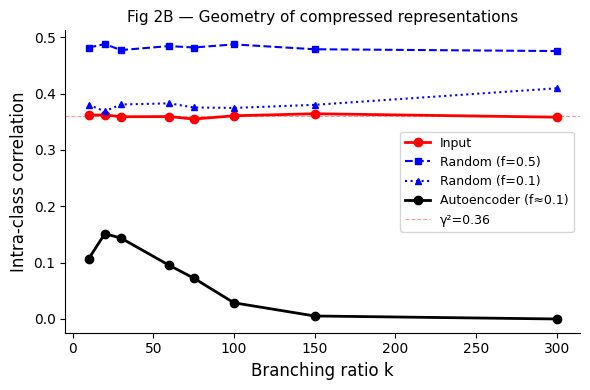

Saved to ../results/figs/fig2/fig2b_correlations.png


In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

k_arr = np.array(res2b['k'])
ax.plot(k_arr, res2b['inp'],    'r-o',  ms=6, lw=2, label='Input')
ax.plot(k_arr, res2b['rand05'], 'b--s', ms=5, lw=1.5, label='Random (f=0.5)')
ax.plot(k_arr, res2b['rand01'], 'b:^',  ms=5, lw=1.5, label='Random (f=0.1)')
ax.plot(k_arr, res2b['ae'],     'k-o',  ms=6, lw=2, label='Autoencoder (f≈0.1)')
ax.axhline(GAMMA**2, color='r', lw=0.8, ls='--', alpha=0.4, label=f'γ²={GAMMA**2:.2f}')

ax.set_xlabel('Branching ratio k', fontsize=12)
ax.set_ylabel('Intra-class correlation', fontsize=12)
ax.set_title('Fig 2B — Geometry of compressed representations', fontsize=11)
ax.legend(fontsize=9, framealpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/figs/fig2/fig2b_correlations.png', dpi=150)
plt.show()
print('Saved to ../results/figs/fig2/fig2b_correlations.png')

## 4. Figure 2C — Memory capacity

**Protocol:**
1. Train autoencoder on all P = p × k patterns
2. Get binarised hidden representations h_bin
3. Train a linear SVM readout: h_bin → input (one classifier per input neuron)
4. Generate noisy cues: flip ~10% of bits (→ Pearson overlap ≈ 0.8 with original)
5. Encode noisy cue → binarise → readout → reconstructed pattern
6. Count memories correctly reconstructed (overlap ≥ 0.9 with original)

**Comparison:** autoencoder vs random encoder (same architecture, random weights).

> The random encoder baseline and input baseline are expected to perform much worse.

In [7]:
def noisy_cue(X, p_flip=0.1, seed=SEED):
    """Flip each bit independently with prob p_flip → Pearson overlap ≈ 1-2*p_flip."""
    rng = np.random.default_rng(seed)
    mask = rng.random(X.shape) < p_flip
    return np.where(mask, 1 - X, X).astype(np.float32)


def pearson_batch(A, B):
    """Pearson correlation for each row pair (A[i], B[i]). Returns (n,) array."""
    A = A - A.mean(axis=1, keepdims=True)
    B = B - B.mean(axis=1, keepdims=True)
    num = (A * B).sum(axis=1)
    den = np.sqrt((A**2).sum(axis=1) * (B**2).sum(axis=1))
    return np.where(den > 1e-10, num / den, 0.0)


def train_readout(h_bin, X):
    """
    Train one LinearSVC per input neuron.
    Returns list of fitted classifiers (length N_INPUT).
    """
    clfs = []
    y_all = X.astype(int)
    for j in range(X.shape[1]):
        y = y_all[:, j]
        if len(np.unique(y)) < 2:        # degenerate: predict majority
            clfs.append(int(y[0]))
        else:
            clf = LinearSVC(max_iter=500, C=1.0)
            clf.fit(h_bin, y)
            clfs.append(clf)
    return clfs


def readout_predict(clfs, h_bin):
    """Reconstruct input pattern from binarised hidden reps."""
    out = np.zeros((len(h_bin), len(clfs)), dtype=np.float32)
    for j, clf in enumerate(clfs):
        out[:, j] = clf if isinstance(clf, int) else clf.predict(h_bin)
    return out


def assess_capacity(desc, lbl, use_random=False,
                    rho=FSPARSE, cue_flip=0.1, recon_thr=0.9,
                    n_epochs=N_EPOCHS, seed=SEED):
    """
    Return number of correctly reconstructed memories.
    If use_random=True, skip training and use a random encoder instead.
    """
    if use_random:
        h_bin_clean = rand_encoder(desc, N_HIDDEN, rho, seed=seed)
        h_bin_noisy = rand_encoder(noisy_cue(desc, cue_flip, seed), N_HIDDEN, rho, seed=seed)
    else:
        model = train_ae(desc, rho=rho, n_epochs=n_epochs, seed=seed)
        _, h_bin_clean = get_hidden(model, desc)
        _, h_bin_noisy = get_hidden(model, noisy_cue(desc, cue_flip, seed))

    clfs = train_readout(h_bin_clean, desc)
    recon = readout_predict(clfs, h_bin_noisy)
    ov = pearson_batch(recon, desc)
    return int((ov >= recon_thr).sum())


print('Capacity functions defined.')

Capacity functions defined.


In [8]:
# ── Fig 2C training loop ───────────────────────────────────────────────────
# Fix branching ratio, vary number of ancestors p → total patterns P = p * k
# Paper uses k=2 (lighter curves) and k=20 (darker curves)

K_VALS_2C   = [2, 20]
P_ANCESTORS = [1, 2, 3, 4, 5, 7, 9, 12, 15, 18, 22]   # range of ancestor counts
# (total memories = p * k, so for k=20 this goes up to 440)

res2c = {k: {'P_ae': [], 'n_ae': [], 'P_rand': [], 'n_rand': []} for k in K_VALS_2C}

for k in K_VALS_2C:
    print(f'\n=== k={k} ===')
    rho = 0.075 if k == 20 else 0.1    # optimal f from paper (Fig 2C legend)

    for p in P_ANCESTORS:
        P = p * k
        _, desc, lbl = generate_ultrametric(N_INPUT, p, k, GAMMA, seed=SEED + p)

        n_ae   = assess_capacity(desc, lbl, use_random=False, rho=rho, seed=SEED + p)
        n_rand = assess_capacity(desc, lbl, use_random=True,  rho=rho, seed=SEED + p)

        res2c[k]['P_ae'].append(P)
        res2c[k]['n_ae'].append(n_ae)
        res2c[k]['P_rand'].append(P)
        res2c[k]['n_rand'].append(n_rand)

        print(f'  p={p:3d}, P={P:4d}: AE={n_ae:4d} correct, rand={n_rand:4d} correct')


=== k=2 ===
  p=  1, P=   2: AE=   0 correct, rand=   2 correct
  p=  2, P=   4: AE=   0 correct, rand=   4 correct
  p=  3, P=   6: AE=   3 correct, rand=   6 correct
  p=  4, P=   8: AE=   7 correct, rand=   7 correct
  p=  5, P=  10: AE=  10 correct, rand=   9 correct
  p=  7, P=  14: AE=  14 correct, rand=  12 correct
  p=  9, P=  18: AE=  18 correct, rand=  16 correct
  p= 12, P=  24: AE=  24 correct, rand=  21 correct
  p= 15, P=  30: AE=  30 correct, rand=  15 correct
  p= 18, P=  36: AE=  36 correct, rand=  17 correct
  p= 22, P=  44: AE=  35 correct, rand=  15 correct

=== k=20 ===
  p=  1, P=  20: AE=  15 correct, rand=   0 correct
  p=  2, P=  40: AE=  15 correct, rand=   0 correct
  p=  3, P=  60: AE=  16 correct, rand=   0 correct
  p=  4, P=  80: AE=  27 correct, rand=   0 correct
  p=  5, P= 100: AE=  27 correct, rand=   0 correct
  p=  7, P= 140: AE=  21 correct, rand=   0 correct
  p=  9, P= 180: AE=  13 correct, rand=   0 correct
  p= 12, P= 240: AE=  21 correct, ran

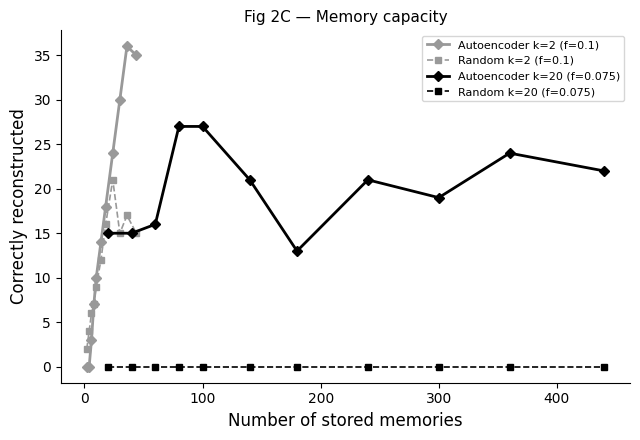

Saved to ../results/figs/fig2/fig2c_capacity.png


In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Colour scheme: k=20 dark, k=2 light (like paper)
colors = {20: 'k', 2: '0.6'}

for k in K_VALS_2C:
    d = res2c[k]
    c = colors[k]
    rho = 0.075 if k == 20 else 0.1
    ax.plot(d['P_ae'],   d['n_ae'],   color=c, lw=2,   marker='D', ms=5,
            label=f'Autoencoder k={k} (f={rho})')
    ax.plot(d['P_rand'], d['n_rand'], color=c, lw=1.2, marker='s', ms=4,
            ls='--', label=f'Random k={k} (f={rho})')

ax.set_xlabel('Number of stored memories', fontsize=12)
ax.set_ylabel('Correctly reconstructed', fontsize=12)
ax.set_title('Fig 2C — Memory capacity', fontsize=11)
ax.legend(fontsize=8, framealpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/figs/fig2/fig2c_capacity.png', dpi=150)
plt.show()
print('Saved to ../results/figs/fig2/fig2c_capacity.png')

## Summary

| Result | Expected (paper) | Status |
|--------|-----------------|--------|
| Input intra-class corr ≈ γ² | 0.36 | ✓ (verified in pattern generation) |
| AE corr decreases with k | Yes (more compressible → more decorrelated) | Check Fig 2B |
| AE outperforms random on capacity | Yes, substantially | Check Fig 2C |
| Larger k gives higher AE capacity | Yes | Check Fig 2C |

**What's different from MATLAB paper:**
- Optimiser: Adam (paper used scaled conjugate gradient via `trainAutoencoder`)
- Readout: scikit-learn `LinearSVC` (paper used MATLAB's `fitclinear`)
- These are functionally equivalent; results should be qualitatively the same.

**Next step:** Step 3 — compress sensory inputs from a simulated navigation task → place cells emerge.